In [1]:
#Import libraries
import pandas as pd
import numpy as np 
import matplotlib.pyplot as plt
import seaborn as sns 

import warnings
warnings.filterwarnings('ignore')

In [2]:
#Descargo de kaggke 
#import kagglehub

# Download latest version
#path = kagglehub.dataset_download("abdelfattahibrahim/marketing-sales-dataset")

#print("Path to dataset files:", path)

df=pd.read_csv('marketing_sales_dataset.csv')
df.head().transpose()

,0,1,2,3,4
id,1,2,3,4,5
date,2020-11-12,2022-07-05,2020-11-11,2022-10-01,2023-12-12
region,Riyadh,Dubai,Riyadh,Cairo,Cairo
sales_channel,Retail Store,Online,Online,Online,Retail Store
product_category,Cosmetics,Cosmetics,Electronics,Electronics,Food & Beverage
customer_segment,Regular,New,Regular,Regular,Corporate
season,Q4,Q3,Q4,Q4,Q4
marketing_budget_usd,1664.51,2452.29,1026.13,1102.86,2517.55
ad_spend_online_usd,952.3,1014.25,328.3,628.3,777.24
ad_spend_offline_usd,326.97,414.76,242.72,204.58,817.88


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 23 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   id                           60000 non-null  int64  
 1   date                         60000 non-null  str    
 2   region                       60000 non-null  str    
 3   sales_channel                60000 non-null  str    
 4   product_category             60000 non-null  str    
 5   customer_segment             60000 non-null  str    
 6   season                       60000 non-null  str    
 7   marketing_budget_usd         60000 non-null  float64
 8   ad_spend_online_usd          60000 non-null  float64
 9   ad_spend_offline_usd         60000 non-null  float64
 10  num_promotions               60000 non-null  int64  
 11  discount_percentage          58192 non-null  float64
 12  num_sales_representatives    60000 non-null  int64  
 13  customer_age               

In [4]:
df=df.drop_duplicates()
#df.info()

#quito columna id, no aporta información útil por ahora
df=df.drop(columns=['id'])


In [5]:
# TRATAMIENTO DE VALORES NULOS 
print(f"VALORES NULOS")
print(df.isnull().sum())
print("="*50)
print(f"PORCENTAJE DE VALORES NULOS")
print((df.isna().sum()/len(df)) * 100)

VALORES NULOS
date                              0
region                            0
sales_channel                     0
product_category                  0
customer_segment                  0
season                            0
marketing_budget_usd              0
ad_spend_online_usd               0
ad_spend_offline_usd              0
num_promotions                    0
discount_percentage            1808
num_sales_representatives         0
customer_age                      0
customer_satisfaction_score    1844
competitor_price_index            0
website_traffic                   0
conversion_rate                   0
email_open_rate                1790
social_media_followers            0
days_since_last_purchase       1836
num_previous_purchases            0
sales_revenue_usd                 0
dtype: int64
PORCENTAJE DE VALORES NULOS
date                           0.000000
region                         0.000000
sales_channel                  0.000000
product_category               0.

In [ ]:
#reemplazo valores nulos por la media
#change null values with mean 

df[['discount_percentage','customer_satisfaction_score','email_open_rate','days_since_last_purchase']]=df[['discount_percentage','customer_satisfaction_score','email_open_rate','days_since_last_purchase']].fillna(df[['discount_percentage','customer_satisfaction_score','email_open_rate','days_since_last_purchase']].mean())


#convierto tipo de datos de la columna date de tipo str a datetime
df['date']=pd.to_datetime(df['date'])



#Agrego columna que contenga  año 
df['year']=df['date'].dt.year


#Cambio el tipo de dato a categoria pues son pocos años los que abarca
df['year']=df['year'].astype('category')


# las columnas con datos tipo str las convierto a tipo category pues contienen pocas entradas
df[['region','sales_channel','product_category','customer_segment','season']]=df[['region','sales_channel','product_category','customer_segment','season']].astype('category')

#df.info()

In [9]:

cat_cols=df.select_dtypes('category')
num_cols=df.select_dtypes(['float64','int64'])
print(cat_cols.info())
print(num_cols.info())

<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype   
---  ------            --------------  -----   
 0   region            60000 non-null  category
 1   sales_channel     60000 non-null  category
 2   product_category  60000 non-null  category
 3   customer_segment  60000 non-null  category
 4   season            60000 non-null  category
 5   year              60000 non-null  category
dtypes: category(6)
memory usage: 352.1 KB
None
<class 'pandas.DataFrame'>
RangeIndex: 60000 entries, 0 to 59999
Data columns (total 16 columns):
 #   Column                       Non-Null Count  Dtype  
---  ------                       --------------  -----  
 0   marketing_budget_usd         60000 non-null  float64
 1   ad_spend_online_usd          60000 non-null  float64
 2   ad_spend_offline_usd         60000 non-null  float64
 3   num_promotions               60000 non-null  int64  
 4   discount_percentage 

In [10]:
num_cols.head().transpose()

,0,1,2,3,4
marketing_budget_usd,1664.5100,2452.2900,1026.1300,1102.8600,2517.5500
ad_spend_online_usd,952.3000,1014.2500,328.3000,628.3000,777.2400
ad_spend_offline_usd,326.9700,414.7600,242.7200,204.5800,817.8800
num_promotions,5.0000,4.0000,8.0000,1.0000,6.0000
discount_percentage,23.4000,6.0000,11.5000,26.7000,38.8000
num_sales_representatives,24.0000,48.0000,12.0000,32.0000,35.0000
customer_age,42.0000,24.0000,32.0000,62.0000,23.0000
customer_satisfaction_score,4.5000,3.7000,2.0000,2.6000,3.0000
competitor_price_index,0.7600,1.0700,1.1800,0.8600,1.0100
website_traffic,1952.0000,3185.0000,1304.0000,1609.0000,366639.0000


In [11]:
#busco inconsistencias en las entradas de los datos categóricos
for col in cat_cols:
    print(col.center(80,"*"))      
    print(cat_cols[col].unique())
    print("_"*100)

*************************************region*************************************
['Riyadh', 'Dubai', 'Cairo', 'Casablanca', 'Alexandria', 'Kuwait', 'Amman']
Categories (7, str): ['Alexandria', 'Amman', 'Cairo', 'Casablanca', 'Dubai', 'Kuwait', 'Riyadh']
____________________________________________________________________________________________________
*********************************sales_channel**********************************
['Retail Store', 'Online', 'Direct Sales', 'Wholesale', 'Social Media']
Categories (5, str): ['Direct Sales', 'Online', 'Retail Store', 'Social Media', 'Wholesale']
____________________________________________________________________________________________________
********************************product_category********************************
['Cosmetics', 'Electronics', 'Food & Beverage', 'Home Appliances', 'Clothing']
Categories (5, str): ['Clothing', 'Cosmetics', 'Electronics', 'Food & Beverage', 'Home Appliances']
______________________________________

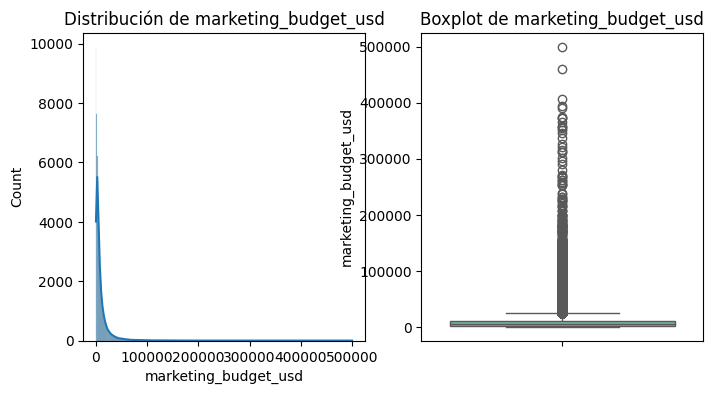

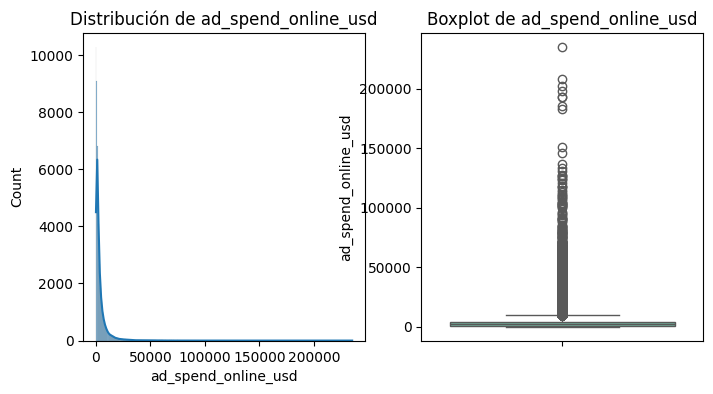

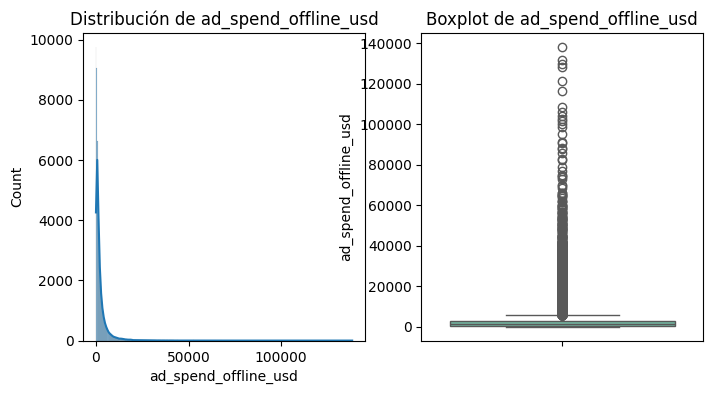

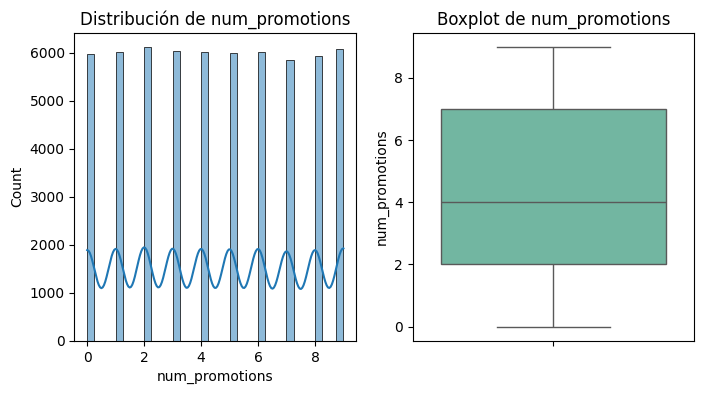

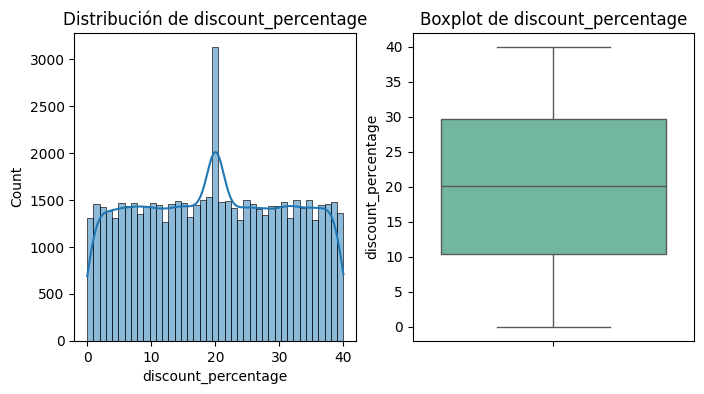

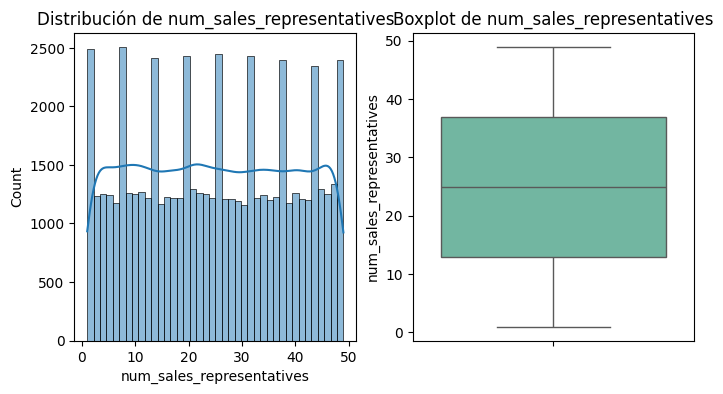

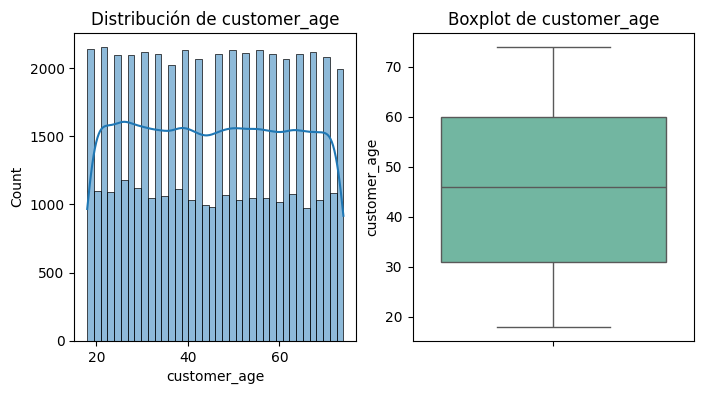

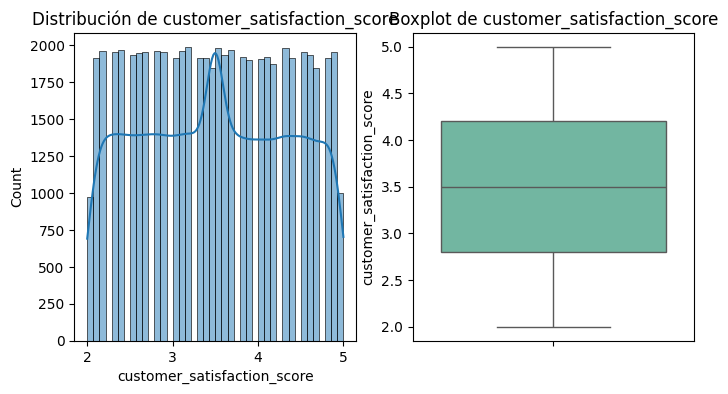

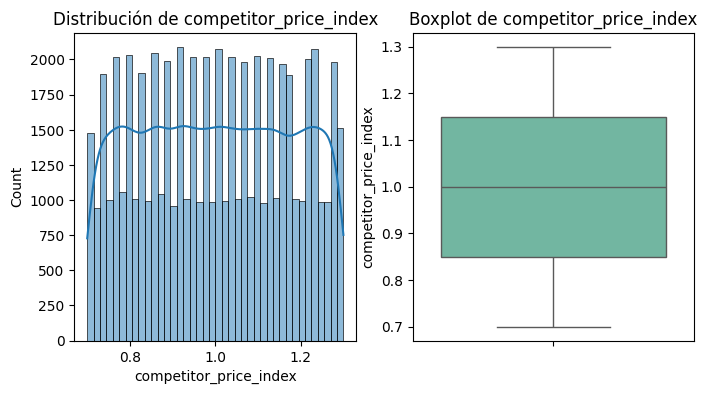

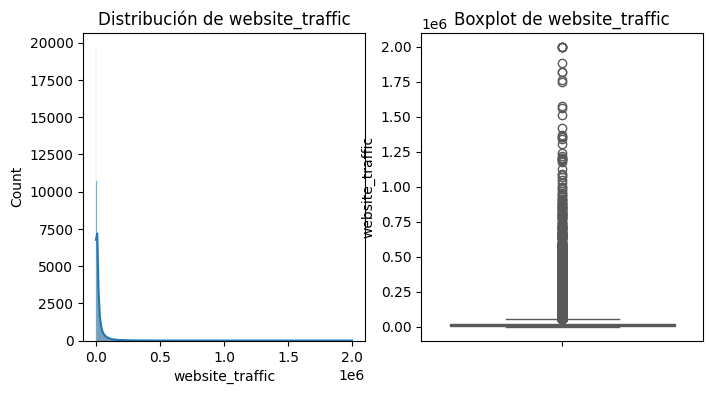

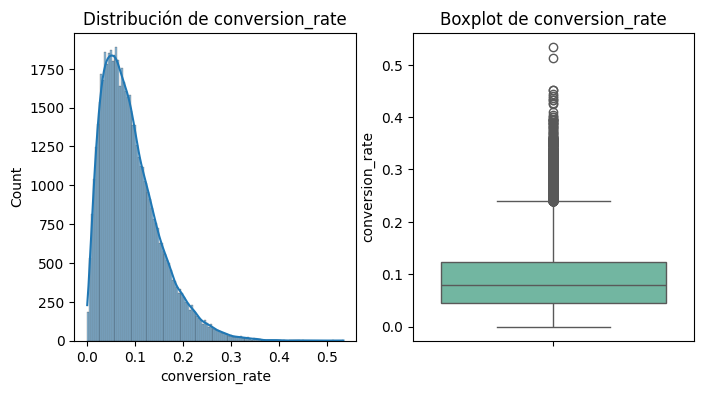

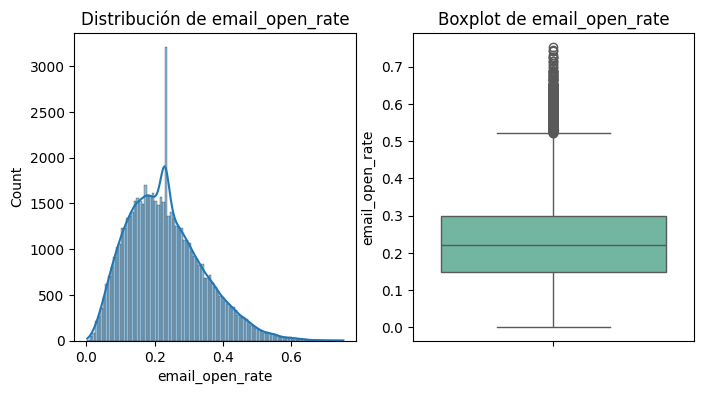

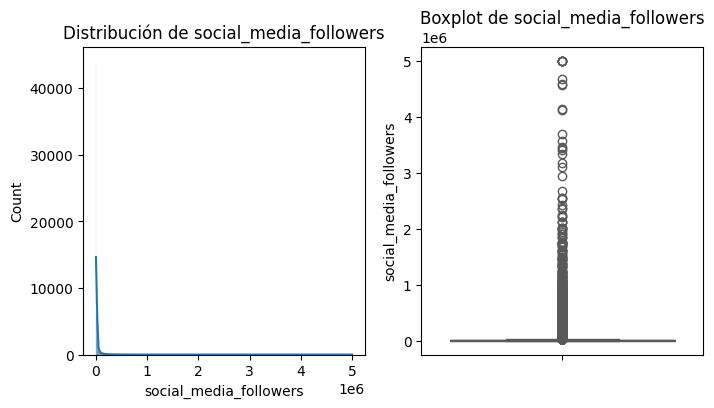

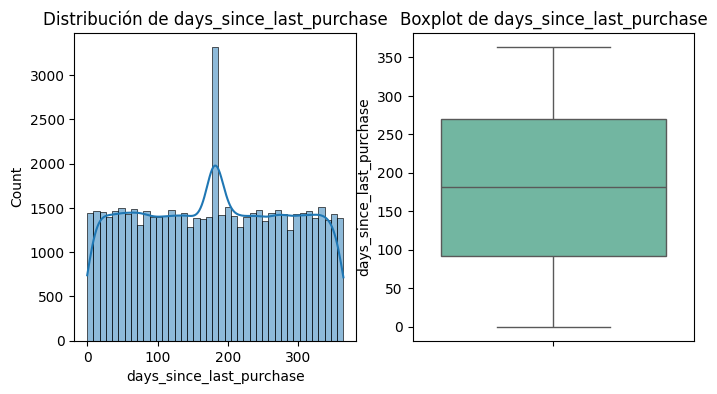

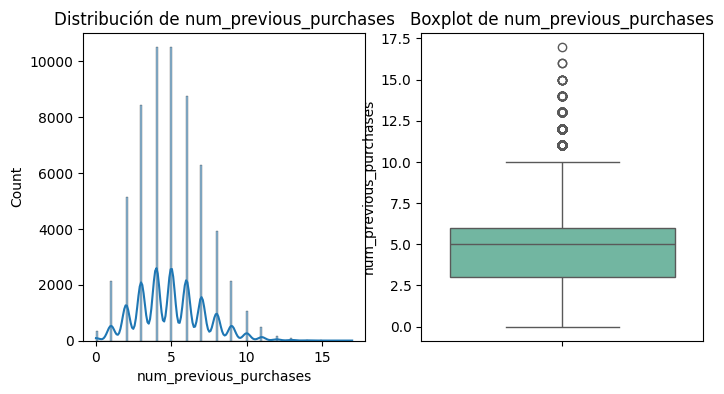

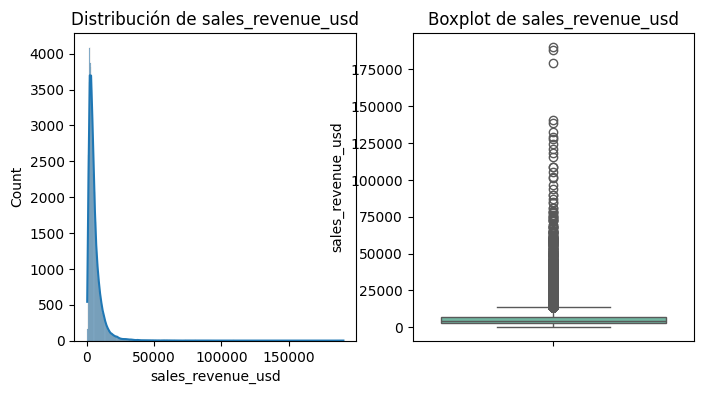

In [12]:
#visualización de datos numéricos
for col in num_cols:
    plt.figure(figsize=(8,4))
    plt.subplot(1,2,1)
    sns.histplot(df[col],kde=True,palette='Set3')
    plt.title(f'Distribución de {col}')

    plt.subplot(1,2,2)
    sns.boxplot(y=df[col],palette='Set2')
    plt.title(f'Boxplot de {col}')
    plt.show

In [13]:
cat_cols.head()

,region,sales_channel,product_category,customer_segment,season,year
0,Riyadh,Retail Store,Cosmetics,Regular,Q4,2020
1,Dubai,Online,Cosmetics,New,Q3,2022
2,Riyadh,Online,Electronics,Regular,Q4,2020
3,Cairo,Online,Electronics,Regular,Q4,2022
4,Cairo,Retail Store,Food & Beverage,Corporate,Q4,2023


distribución de region:
region
Cairo         0.249733
Riyadh        0.199517
Dubai         0.181500
Alexandria    0.150450
Kuwait        0.078983
Amman         0.070100
Casablanca    0.069717
Name: proportion, dtype: float64


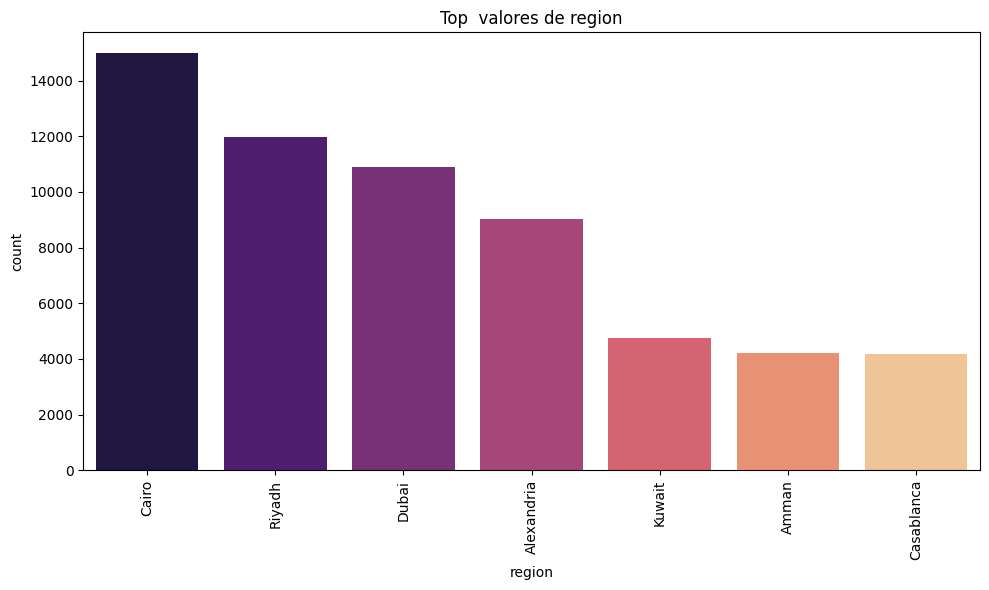

distribución de sales_channel:
sales_channel
Online          0.300167
Retail Store    0.249233
Wholesale       0.199783
Direct Sales    0.153483
Social Media    0.097333
Name: proportion, dtype: float64


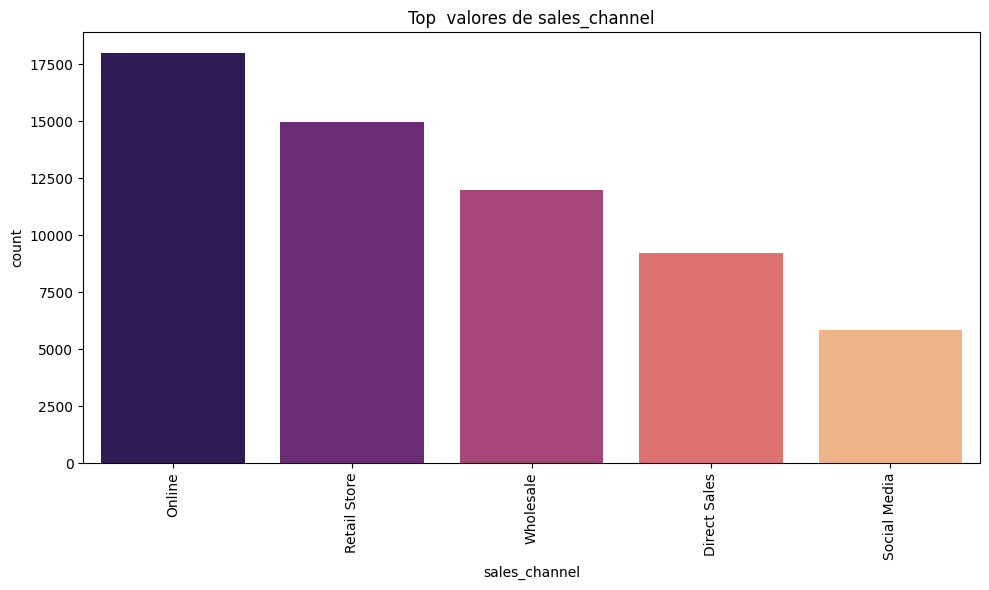

distribución de product_category:
product_category
Food & Beverage    0.250383
Electronics        0.218633
Clothing           0.200267
Home Appliances    0.179583
Cosmetics          0.151133
Name: proportion, dtype: float64


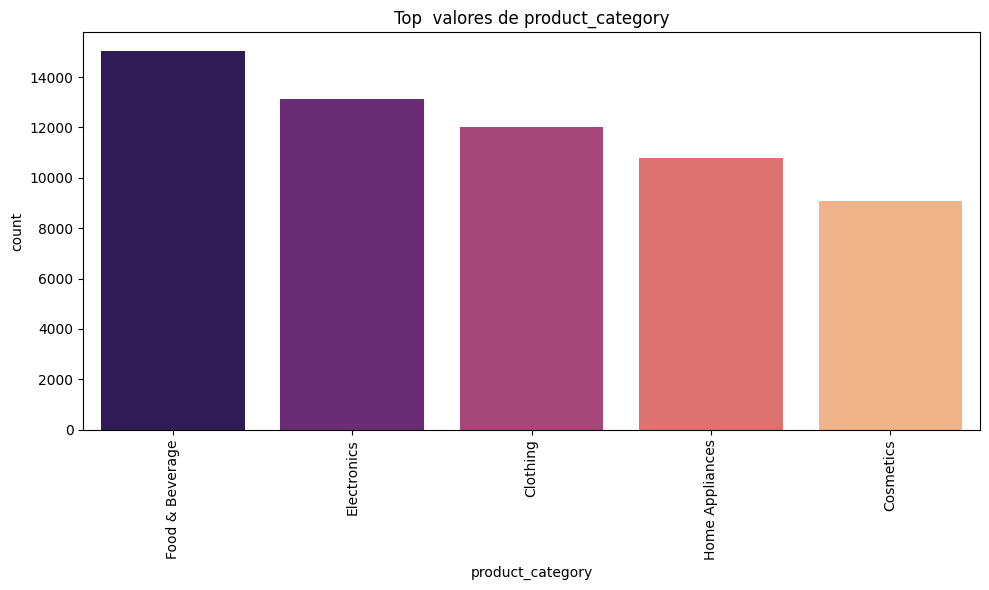

distribución de customer_segment:
customer_segment
Regular      0.398433
New          0.300183
Corporate    0.151883
VIP          0.149500
Name: proportion, dtype: float64


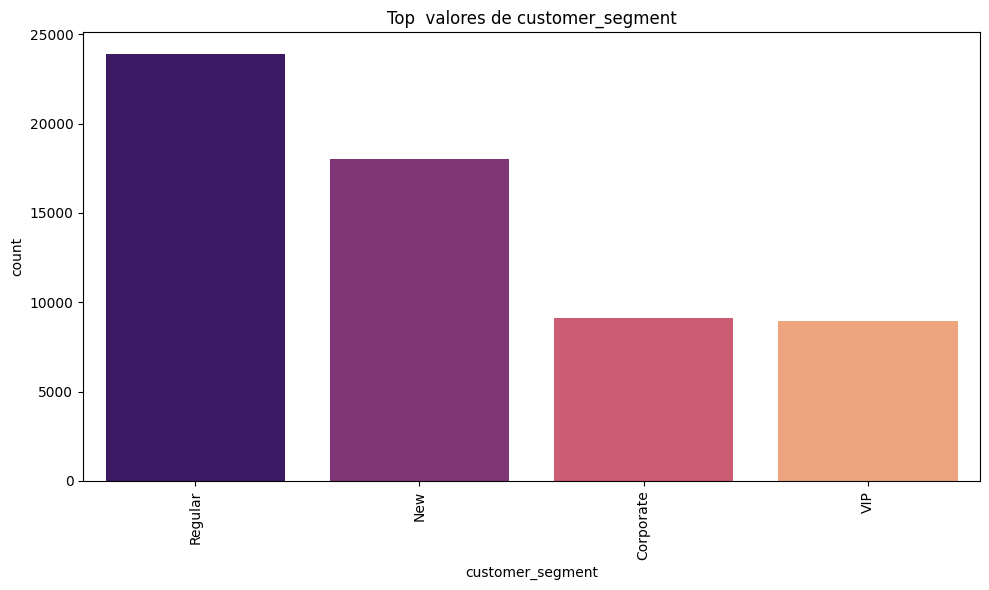

distribución de season:
season
Q3    0.252067
Q4    0.250400
Q2    0.249233
Q1    0.248300
Name: proportion, dtype: float64


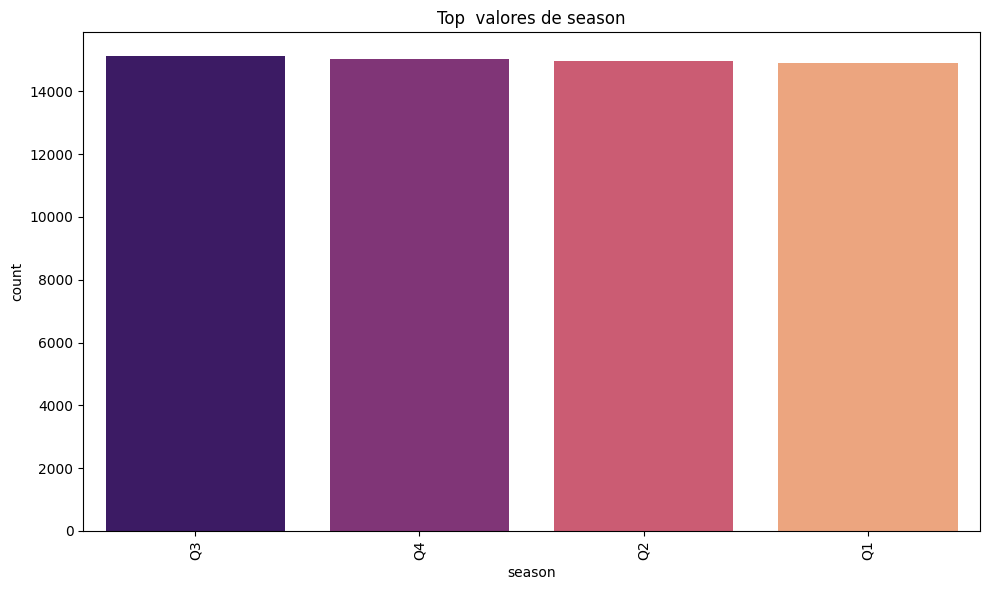

distribución de year:
year
2022    0.252017
2023    0.251650
2020    0.250200
2021    0.246133
Name: proportion, dtype: float64


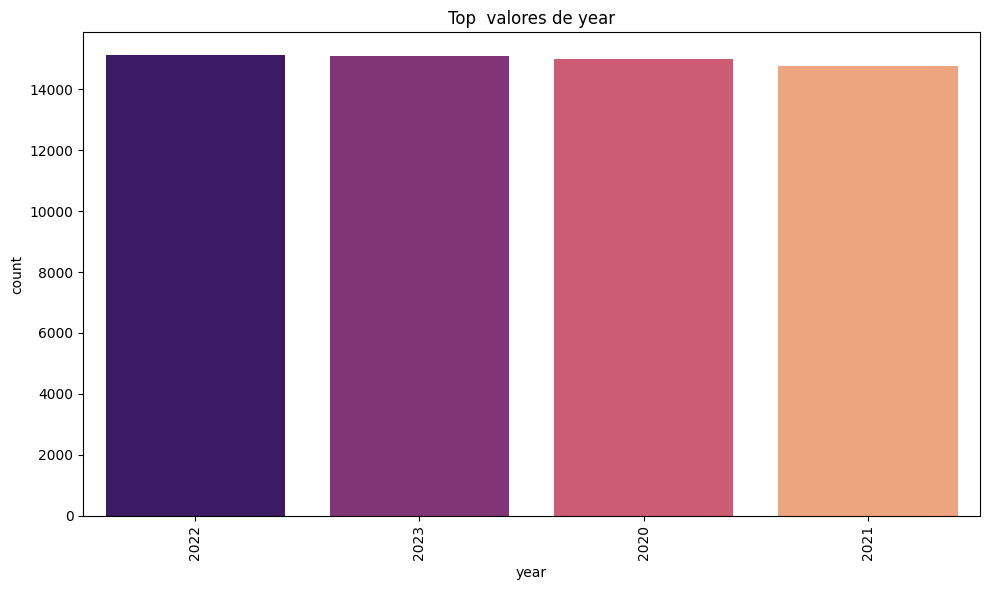

In [14]:
#gráficos de columnas categóricas


for column in cat_cols:
    print(f'distribución de {column}:')
    print(cat_cols[column].value_counts(normalize=True).head(10))

    top_cat=cat_cols[column].value_counts().head(10).index.tolist()

    temp_filt=cat_cols[cat_cols[column].isin(top_cat)].copy()

     # Crear el gráfico
    plt.figure(figsize=(10, 6))
    
    # Ordenar las categorías por frecuencia (opcional pero recomendado)
    order = temp_filt[column].value_counts().index
    
    sns.countplot(x=column, data=temp_filt, order=order,palette='magma')
    plt.xticks(rotation=90)
    plt.title(f'Top  valores de {column}')
    plt.tight_layout()
    plt.show()


======================  Preguntas del negocio  ======================== 

Se plantean algunas preguntas y respuestas que pudieran resultar de interés para el negocio.


qué categoria de producto genera la mayor ganancia? 

En qué temporada se tiene la mayor ganancia ?

En qué región se registran las mayores ganancias?

Qué segmento de clientes genera la mayor ganancia?

Cómo cambia la ganancia respecto al tiempo ?

  product_category       revenue
0      Electronics  1.045776e+08
1  Home Appliances  7.414371e+07
2  Food & Beverage  6.981506e+07
3         Clothing  5.896592e+07
4        Cosmetics  4.716483e+07


Text(0.5, 1.0, 'product_category vs revenue')

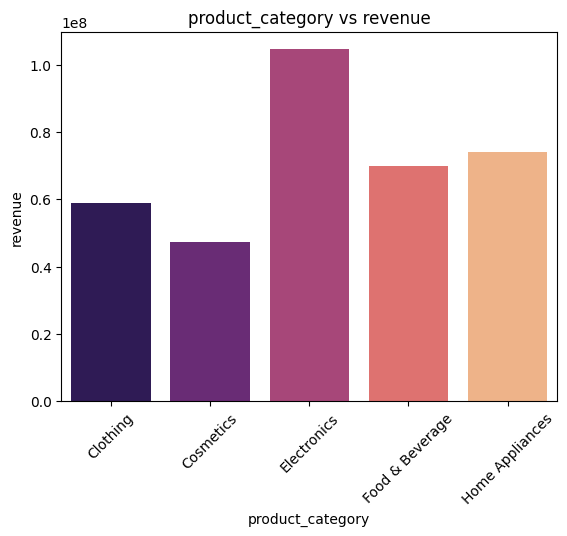

In [16]:
#revenue by product_category
rev_cat=df.groupby('product_category').agg(revenue=('sales_revenue_usd','sum')).sort_values('revenue',ascending=False).reset_index()

print(rev_cat)

sns.barplot(rev_cat,x='product_category',y='revenue',palette='magma')
plt.xticks(rotation=45)
plt.title('product_category vs revenue')

In [17]:
#revenue by season
rev_sea=df.groupby('season').agg(revenue=('sales_revenue_usd','sum')).sort_values('revenue',ascending=False).reset_index()

rev_sea

,season,revenue
0,Q4,1.134122e+08
1,Q3,8.909859e+07
2,Q2,8.144633e+07
3,Q1,7.071008e+07


       region      revenue
0       Cairo  88897812.67
1      Riyadh  69878924.02
2       Dubai  64017782.13
3  Alexandria  53535698.32
4      Kuwait  28158938.76
5       Amman  25294385.80
6  Casablanca  24883610.68


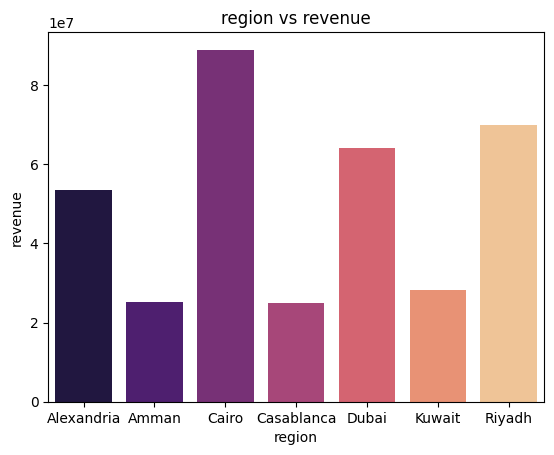

In [18]:
rev_reg=df.groupby('region').agg(revenue=('sales_revenue_usd','sum')).sort_values('revenue',ascending=False).reset_index()
print(rev_reg)
sns.barplot(rev_reg,x='region',y='revenue', palette='magma')
plt.title('region vs revenue')
plt.show()

  customer_segment       revenue
0          Regular  1.164208e+08
1        Corporate  9.729028e+07
2              VIP  7.933241e+07
3              New  6.162372e+07


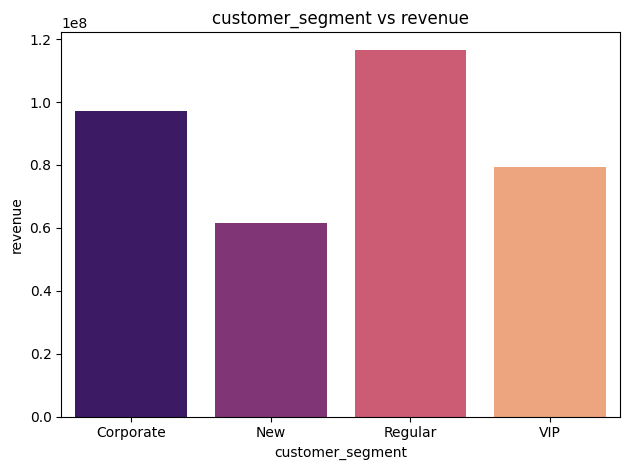

In [19]:
rev_cus=df.groupby('customer_segment').agg(revenue=('sales_revenue_usd','sum')).sort_values('revenue',ascending=False).reset_index()
print(rev_cus)
sns.barplot(rev_cus,x='customer_segment',y='revenue',palette='magma')
#plt.xticks(rotation=90)
plt.title('customer_segment vs revenue')
plt.tight_layout()
plt.show()

   year      revenue
0  2023  89934448.20
1  2022  89703546.03
2  2020  88422226.37
3  2021  86606931.78


<Axes: xlabel='year', ylabel='revenue'>

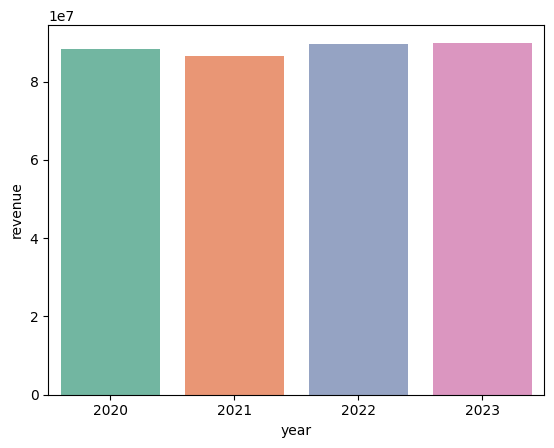

In [20]:
rev_yr=df.groupby('year').agg(revenue=('sales_revenue_usd','sum')).sort_values('revenue',ascending=False).reset_index()
print(rev_yr)
sns.barplot(rev_yr,x='year',y='revenue' ,palette='Set2')

  sales_channel       revenue
0        Online  1.100419e+08
1  Retail Store  8.413866e+07
2     Wholesale  8.012158e+07
3  Direct Sales  4.684377e+07
4  Social Media  3.352123e+07


<Axes: xlabel='sales_channel', ylabel='revenue'>

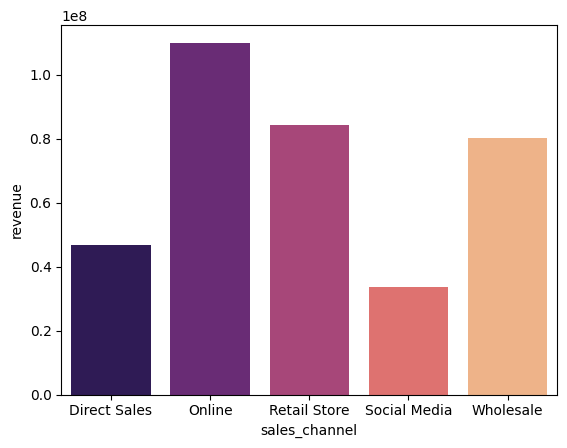

In [21]:
rev_ch=df.groupby('sales_channel').agg(revenue=('sales_revenue_usd','sum')).sort_values('revenue',ascending=False).reset_index()
print(rev_ch)
sns.barplot(rev_ch,x='sales_channel',y='revenue' ,palette='magma')

  age_range      revenue
0     26-35  62844541.08
1     36-45  62310161.67
2     56-65  62054631.53
3       65+  62017337.00
4     46-55  61396798.34
5     19-25  44043682.76


<Axes: xlabel='age_range', ylabel='revenue'>

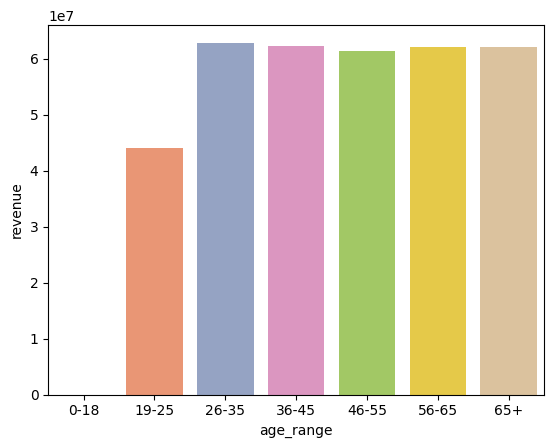

In [22]:
# Definir rangos de edades
bins = [0, 18, 25, 35, 45, 55, 65, 100]
labels = ['0-18', '19-25', '26-35', '36-45', '46-55', '56-65', '65+']

# Crear columna con rangos de edad
df['age_range'] = pd.cut(df['customer_age'], bins=bins, labels=labels, right=False)

# Agrupar por rangos de edad
rev_age = df.groupby('age_range').agg(revenue=('sales_revenue_usd', 'sum')).sort_values('revenue', ascending=False).reset_index()
print(rev_age)

sns.barplot(rev_age,x='age_range',y='revenue' ,palette='Set2')